# Importing Packages and Modules

In [42]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, f1_score, precision_recall_curve,
    average_precision_score
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier  # handles NaN natively
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from dotenv import load_dotenv
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import warnings
import joblib
warnings.filterwarnings("ignore")

In [43]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print(" xgboost not installed. Run: pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print(" lightgbm not installed. Run: pip install lightgbm")

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False
    print(" catboost not installed. Run: pip install catboost")

# Loading Env

In [44]:
# 1. Load the .env file
load_dotenv()

True

# Constants

In [45]:
PATH_SEP = os.sep

# Reading Data

### Paths

In [46]:
folder_path=os.getenv("PROCESS_DATA_FOLDER")
model_folder = os.getenv("MODEL_FOLDER")
renewal_calls_file_path = folder_path+PATH_SEP+'renewal_processed.csv'
billings_file_path=folder_path+PATH_SEP+'billings_processed.csv'
cc_calls_file_path=folder_path+PATH_SEP+'cc_calls_processed.csv'
processed_emails_file_path=folder_path+PATH_SEP+'processed_emails.csv'
model_file_path = model_folder + PATH_SEP + '01_churn_model_with_crm.pkl'

In [6]:

renewal_calls = pd.read_csv(renewal_calls_file_path)
billings = pd.read_csv(billings_file_path)
cc_calls=pd.read_csv(cc_calls_file_path)
emails=pd.read_csv(processed_emails_file_path)

# Joining Dataframes

In [7]:
# Rename renewal_calls column to match other dataframes
renewal_calls = renewal_calls.rename(columns={'co_ref': 'Co_Ref'})

# Inner join renewal_calls with billings on Co_Ref
billings_revenue_df = renewal_calls.merge(billings, on='Co_Ref', how='inner')

# Left join cc_calls to the result
billings_revenue_df = billings_revenue_df.merge(cc_calls, on='Co_Ref', how='left')

# Display the result
joined_df=billings_revenue_df.merge(emails, on='Co_Ref', how='left')

# Saving External Data

In [8]:
external_data_folder = os.getenv("EXTERNAL_DATA_FOLDER")
external_data_file_path = external_data_folder + PATH_SEP + "external_data.csv"
save_format_df = joined_df.drop(['Co_Ref','Prospect_Outcome'], axis=1)

In [9]:
save_format_df.to_csv(external_data_file_path, index=False)

# Scaling Numerical Columns

In [10]:
df=save_format_df.copy()
bool_cols = [
    "reaction_clarification___justification___inquiry",
    "reaction_dissatisfaction___concern___complaint___frustration",
    "reaction_not_mentioned", "reaction_other",
    "agent_accreditation_and_certification", "agent_auto___automatic",
    "agent_cancellation___termination___closure",
    "agent_confirmation___acceptance___agreement",
    "agent_customer_communication", "agent_customer_retention",
    "agent_customer_service___support", "agent_discount_and_offer",
    "agent_not_mentioned", "agent_other", "agent_payment",
    "agent_price_and_cost",
]


In [11]:
TARGET = "churn"
DROP_COLS = [TARGET]          

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

bool_features = X.select_dtypes(include="bool").columns.tolist()
X[bool_features] = X[bool_features].astype(int)

numeric_cols  = X.select_dtypes(include=[np.number]).columns.tolist()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (28671, 66)  |  Test: (7168, 66)


In [13]:
# Data Leakage Check
# Compute correlation with target for all numeric columns
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(correlations.head(20))

Total_Renewal_Score_New                       0.848323
desire_code                                   0.459724
renewal_decision_bin                          0.455528
total_past_contracts                          0.360920
agent_cancellation___termination___closure    0.317305
crm_customer_payment_intention                0.290072
days_since_last_call                          0.219763
tenure_days                                   0.206691
Tenure_Years                                  0.206047
log_calls                                     0.197057
Total_Calls_In_Window                         0.189884
days_last_call_to_renewal                     0.166076
log_days                                      0.141127
crm_contractor_sentiment_score                0.140588
agent_payment                                 0.130017
Band                                          0.126305
care_package_discussed_flag                   0.121903
total_comp_mentions                           0.093184
crm_agent_

### Dropping Data Leaking Columns

In [14]:
# Drop identified leakage columns and update numeric_cols list
X = X.drop(columns=['Total_Renewal_Score_New', 'renewal_decision_bin'])

numeric_cols.remove("Total_Renewal_Score_New")
numeric_cols.remove("renewal_decision_bin")

# Re-split the data after dropping leakage columns
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (28671, 64)  |  Test: (7168, 64)


In [15]:
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num_scale", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale",  RobustScaler()),
        ]), numeric_cols),
    ],
    remainder="passthrough",
)
tree_identity = FunctionTransformer()

In [16]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model Registry

### Tree Based

In [17]:

# MODEL REGISTRY
models = {}

# ── Tree-based (use tree_preprocessor) ───────────────────────────────────────
models["DecisionTree"] = (
    "tree",
    DecisionTreeClassifier(random_state=42)
)
models["RandomForest"] = (
    "tree",
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
)
models["ExtraTrees"] = (
    "tree",
    ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42)
)
models["GradientBoosting"] = (
    "scaled_tree",
    GradientBoostingClassifier(n_estimators=200, random_state=42)
)
models["HistGradientBoosting"] = (
    "tree",
    HistGradientBoostingClassifier(max_iter=200, random_state=42)
)
if HAS_XGB:
    models["XGBoost"] = (
        "tree",
        XGBClassifier(
            n_estimators=200, use_label_encoder=False,
            eval_metric="logloss", tree_method="hist",
            n_jobs=-1, random_state=42
        )
    )
if HAS_LGBM:
    models["LightGBM"] = (
        "tree",
        LGBMClassifier(n_estimators=200, n_jobs=-1, random_state=42, verbose=-1)
    )
if HAS_CAT:
    models["CatBoost"] = (
        "tree",
        CatBoostClassifier(iterations=200, verbose=0, random_state=42)
    )

### Non Tree Based

In [18]:
models["LogisticRegression"] = (
    "scaled",
    LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
)
models["KNN"] = (
    "scaled",
    KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
)
models["SVM"] = (
    "scaled",
    SVC(probability=True, random_state=42)
)
models["MLP"] = (
    "scaled",
    MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
)


# Model Selection 

### Cross Validation Scores

In [19]:
results = []
trained_pipelines = {}

print("\n" + "="*70)
print("  MODEL SELECTION — 5-Fold Stratified CV")
print("="*70)

for name, (pipe_type, estimator) in models.items():
    preprocessor = tree_identity if pipe_type == "tree" else scaled_preprocessor

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model",         estimator),
    ])

    t0 = time()
    try:
        auc_scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=CV, scoring="roc_auc", n_jobs=-1
        )
        f1_scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=CV, scoring="f1", n_jobs=-1
        )
        elapsed = time() - t0

        results.append({
            "Model":       name,
            "Type":        pipe_type,
            "ROC-AUC Mean": auc_scores.mean(),
            "ROC-AUC Std":  auc_scores.std(),
            "F1 Mean":      f1_scores.mean(),
            "F1 Std":       f1_scores.std(),
            "Time (s)":     round(elapsed, 1),
        })
        print(f"  {name:<25} AUC={auc_scores.mean():.4f}±{auc_scores.std():.4f}"
              f"  F1={f1_scores.mean():.4f}  ({elapsed:.1f}s)")

        # Fit on full training set for test-set evaluation later
        pipeline.fit(X_train, y_train)
        trained_pipelines[name] = pipeline

    except Exception as e:
        print(f"  {name:<25}   FAILED: {e}")

results_df = pd.DataFrame(results).sort_values("ROC-AUC Mean", ascending=False)
print("\n── Ranked Summary ──────────────────────────────────────────────────────")
print(results_df.to_string(index=False))


best_name = results_df.iloc[0]["Model"]
print(f"\n  Best CV model: {best_name}")


  MODEL SELECTION — 5-Fold Stratified CV
  DecisionTree              AUC=0.8045±0.0059  F1=0.6795  (3.5s)
  RandomForest              AUC=0.9417±0.0007  F1=0.7737  (7.5s)
  ExtraTrees                AUC=0.9377±0.0014  F1=0.7574  (7.6s)
  GradientBoosting          AUC=0.9428±0.0024  F1=0.7682  (18.1s)
  HistGradientBoosting      AUC=0.9481±0.0017  F1=0.7803  (2.5s)
  XGBoost                   AUC=0.9423±0.0018  F1=0.7767  (4.8s)
  LightGBM                  AUC=0.9476±0.0019  F1=0.7823  (6.6s)
  CatBoost                  AUC=0.9483±0.0025  F1=0.7811  (4.7s)
  LogisticRegression        AUC=0.9217±0.0028  F1=0.7308  (8.6s)
  KNN                       AUC=0.8686±0.0061  F1=0.6016  (3.1s)
  SVM                       AUC=0.8962±0.0017  F1=0.0214  (304.6s)
  MLP                       AUC=0.8833±0.0050  F1=0.7176  (67.5s)

── Ranked Summary ──────────────────────────────────────────────────────
               Model        Type  ROC-AUC Mean  ROC-AUC Std  F1 Mean   F1 Std  Time (s)
            

### Hold Out Validation

In [20]:
print("\n" + "="*70)
print("  HOLD-OUT TEST EVALUATION")
print("="*70)

test_results = []
for name, pipeline in trained_pipelines.items():
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)
    ap  = average_precision_score(y_test, y_proba)
    test_results.append({"Model": name, "Test AUC": auc, "Test F1": f1, "Avg Precision": ap})
    print(f"  {name:<25} AUC={auc:.4f}  F1={f1:.4f}  AP={ap:.4f}")

test_df = pd.DataFrame(test_results).sort_values("Test AUC", ascending=False)


  HOLD-OUT TEST EVALUATION
  DecisionTree              AUC=0.7943  F1=0.6622  AP=0.5012
  RandomForest              AUC=0.9398  F1=0.7625  AP=0.8507
  ExtraTrees                AUC=0.9338  F1=0.7422  AP=0.8382
  GradientBoosting          AUC=0.9394  F1=0.7593  AP=0.8398
  HistGradientBoosting      AUC=0.9439  F1=0.7771  AP=0.8540
  XGBoost                   AUC=0.9416  F1=0.7768  AP=0.8517
  LightGBM                  AUC=0.9445  F1=0.7795  AP=0.8592
  CatBoost                  AUC=0.9452  F1=0.7803  AP=0.8625
  LogisticRegression        AUC=0.9205  F1=0.7220  AP=0.7956
  KNN                       AUC=0.8734  F1=0.6169  AP=0.6970
  SVM                       AUC=0.8955  F1=0.0214  AP=0.7335
  MLP                       AUC=0.8842  F1=0.6921  AP=0.7098


# Hyperparameter Tuning

In [21]:
top3 = test_df.head(3)["Model"].tolist()
print(f"\n  Tuning top-3 models: {top3}")

# Parameter grids per model
PARAM_GRIDS = {
    "RandomForest": {
        "model__n_estimators":       [200, 400, 600],
        "model__max_depth":          [None, 10, 20, 30],
        "model__min_samples_split":  [2, 5, 10],
        "model__min_samples_leaf":   [1, 2, 4],
        "model__max_features":       ["sqrt", "log2", 0.5],
        "model__class_weight":       [None, "balanced"],
    },
    "ExtraTrees": {
        "model__n_estimators":       [200, 400],
        "model__max_depth":          [None, 15, 30],
        "model__min_samples_split":  [2, 5],
        "model__min_samples_leaf":   [1, 2],
        "model__max_features":       ["sqrt", "log2"],
        "model__class_weight":       [None, "balanced"],
    },
    "GradientBoosting": {
        "model__n_estimators":       [200, 400],
        "model__learning_rate":      [0.01, 0.05, 0.1, 0.2],
        "model__max_depth":          [3, 5, 7],
        "model__subsample":          [0.7, 0.8, 1.0],
        "model__min_samples_split":  [2, 5, 10],
        "model__max_features":       ["sqrt", "log2", None],
    },
    "HistGradientBoosting": {
        "model__max_iter":           [100, 200, 400],
        "model__learning_rate":      [0.01, 0.05, 0.1],
        "model__max_depth":          [None, 5, 10],
        "model__min_samples_leaf":   [10, 20, 50],
        "model__l2_regularization":  [0.0, 0.1, 1.0],
    },
    "XGBoost": {
        "model__n_estimators":       [200, 400, 600],
        "model__learning_rate":      [0.01, 0.05, 0.1, 0.2],
        "model__max_depth":          [3, 5, 7, 9],
        "model__subsample":          [0.6, 0.8, 1.0],
        "model__colsample_bytree":   [0.6, 0.8, 1.0],
        "model__gamma":              [0, 0.1, 0.5],
        "model__reg_alpha":          [0, 0.1, 1.0],
        "model__reg_lambda":         [1, 1.5, 2.0],
        "model__scale_pos_weight":   [1, 3, 5],
    },
    "LightGBM": {
        "model__n_estimators":       [200, 400, 600],
        "model__learning_rate":      [0.01, 0.05, 0.1],
        "model__num_leaves":         [31, 63, 127],
        "model__max_depth":          [-1, 5, 10],
        "model__min_child_samples":  [10, 20, 50],
        "model__subsample":          [0.7, 0.85, 1.0],
        "model__colsample_bytree":   [0.7, 0.85, 1.0],
        "model__reg_alpha":          [0, 0.1, 1.0],
        "model__reg_lambda":         [0, 0.1, 1.0],
        "model__class_weight":       [None, "balanced"],
    },
    "CatBoost": {
        "model__iterations":         [200, 400],
        "model__learning_rate":      [0.01, 0.05, 0.1],
        "model__depth":              [4, 6, 8, 10],
        "model__l2_leaf_reg":        [1, 3, 5, 10],
        "model__border_count":       [32, 64, 128],
    },
    "DecisionTree": {
        "model__max_depth":          [None, 5, 10, 20],
        "model__min_samples_split":  [2, 5, 10, 20],
        "model__min_samples_leaf":   [1, 2, 5, 10],
        "model__criterion":          ["gini", "entropy"],
        "model__class_weight":       [None, "balanced"],
    },
    "LogisticRegression": {
        "model__C":                  [0.001, 0.01, 0.1, 1, 10, 100],
        "model__penalty":            ["l1", "l2", "elasticnet"],
        "model__solver":             ["saga"],
        "model__l1_ratio":           [0.0, 0.25, 0.5, 0.75, 1.0],
        "model__class_weight":       [None, "balanced"],
    },
    "KNN": {
        "model__n_neighbors":        [5, 10, 15, 25, 50],
        "model__weights":            ["uniform", "distance"],
        "model__metric":             ["euclidean", "manhattan", "minkowski"],
        "model__p":                  [1, 2],
    },
    "SVM": {
        "model__C":                  [0.1, 1, 10, 100],
        "model__kernel":             ["rbf", "poly", "sigmoid"],
        "model__gamma":              ["scale", "auto", 0.001, 0.01],
        "model__class_weight":       [None, "balanced"],
    },
    "MLP": {
        "model__hidden_layer_sizes": [(64,), (128,), (128, 64), (256, 128, 64)],
        "model__activation":         ["relu", "tanh"],
        "model__alpha":              [0.0001, 0.001, 0.01],
        "model__learning_rate":      ["constant", "adaptive"],
        "model__dropout":            [0.0],   # sklearn MLP has no native dropout
    },
}

tuned_results = []
best_tuned_pipelines = {}

for name in top3:
    if name not in trained_pipelines:
        print(f"  Skipping {name} — not in trained_pipelines.")
        continue

    param_grid = PARAM_GRIDS.get(name)
    if param_grid is None:
        print(f"  No param grid defined for {name} — skipping tuning.")
        continue

    print(f"\n  Tuning {name} ...")
    base_pipeline = trained_pipelines[name]

    # Remove invalid keys not in estimator (e.g. 'dropout' for MLP)
    valid_params = base_pipeline.get_params().keys()
    param_grid = {k: v for k, v in param_grid.items() if k in valid_params}

    search = RandomizedSearchCV(
        base_pipeline,
        param_distributions=param_grid,
        n_iter=40,
        cv=CV,
        scoring="roc_auc",
        n_jobs=-1,
        random_state=42,
        verbose=0,
        refit=True,
    )
    t0 = time()
    search.fit(X_train, y_train)
    elapsed = time() - t0

    y_pred  = search.best_estimator_.predict(X_test)
    y_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)

    print(f"    Best CV AUC : {search.best_score_:.4f}")
    print(f"    Test  AUC   : {auc:.4f}   F1: {f1:.4f}   ({elapsed:.0f}s)")
    print(f"    Best params : {search.best_params_}")

    tuned_results.append({
        "Model": name,
        "Best CV AUC": search.best_score_,
        "Test AUC":    auc,
        "Test F1":     f1,
        "Best Params": search.best_params_,
    })
    best_tuned_pipelines[name] = search.best_estimator_

tuned_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != "Best Params"} for r in tuned_results]
).sort_values("Test AUC", ascending=False)

print("\n── Tuning Summary ──────────────────────────────────────────────────────")
print(tuned_df.to_string(index=False))

final_best = tuned_df.iloc[0]["Model"]
final_pipeline = best_tuned_pipelines[final_best]
print(f"\n  Final best model: {final_best}")



  Tuning top-3 models: ['CatBoost', 'LightGBM', 'HistGradientBoosting']

  Tuning CatBoost ...
    Best CV AUC : 0.9495
    Test  AUC   : 0.9466   F1: 0.7747   (7s)
    Best params : {'model__iterations': 400}

  Tuning LightGBM ...
    Best CV AUC : 0.9506
    Test  AUC   : 0.9475   F1: 0.7842   (237s)
    Best params : {'model__subsample': 0.7, 'model__reg_lambda': 0, 'model__reg_alpha': 0, 'model__num_leaves': 63, 'model__n_estimators': 600, 'model__min_child_samples': 10, 'model__max_depth': -1, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7, 'model__class_weight': None}

  Tuning HistGradientBoosting ...
    Best CV AUC : 0.9486
    Test  AUC   : 0.9444   F1: 0.7746   (52s)
    Best params : {'model__min_samples_leaf': 10, 'model__max_iter': 200, 'model__max_depth': None, 'model__learning_rate': 0.05, 'model__l2_regularization': 0.1}

── Tuning Summary ──────────────────────────────────────────────────────
               Model  Best CV AUC  Test AUC  Test F1
       

# Final Evaluation

In [22]:
y_pred_final  = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

In [23]:
print(f"\n── Classification Report: {final_best} ─────────────────────────────────")
print(classification_report(y_test, y_pred_final, target_names=["Retained", "Churned"]))


── Classification Report: LightGBM ─────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.94      0.97      0.95      5786
     Churned       0.84      0.73      0.78      1382

    accuracy                           0.92      7168
   macro avg       0.89      0.85      0.87      7168
weighted avg       0.92      0.92      0.92      7168



### Plots

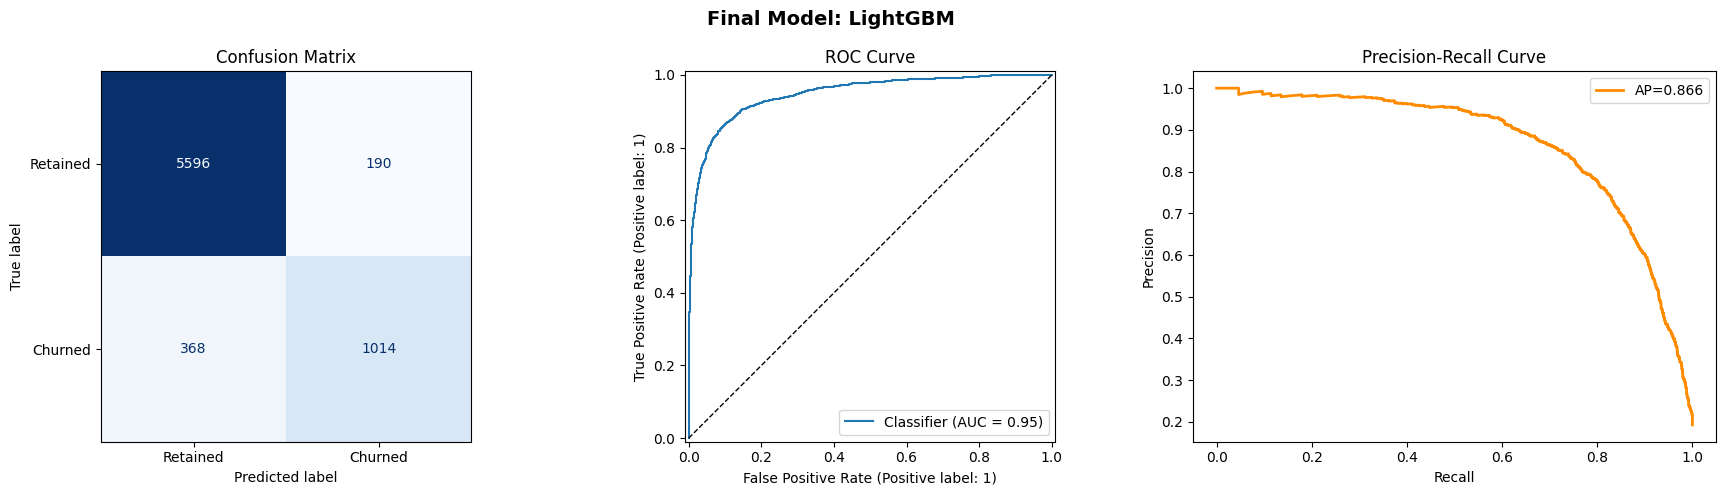

Plots saved to model_evaluation_plots.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Final Model: {final_best}", fontsize=14, fontweight="bold")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)

axes[0].set_title("Confusion Matrix")


# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_final, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curve")


# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba_final)
ap = average_precision_score(y_test, y_proba_final)
axes[2].plot(rec, prec, color="darkorange", lw=2, label=f"AP={ap:.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.savefig("model_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved to model_evaluation_plots.png")

### Model Comparision Chart

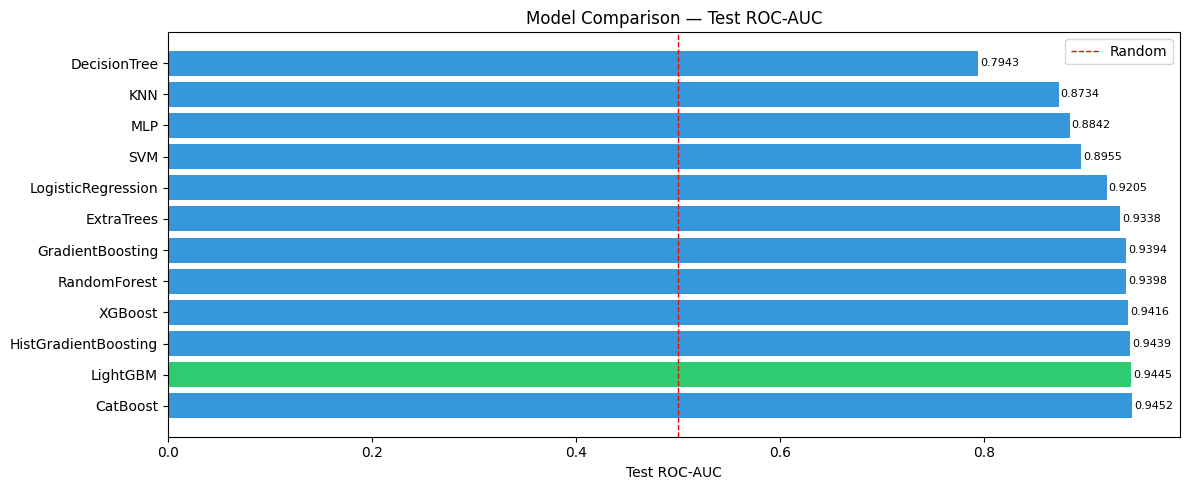

Comparison chart saved to model_comparison.png


In [25]:
# ── Model comparison bar chart ────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ecc71" if m == final_best else "#3498db" for m in test_df["Model"]]
bars = ax.barh(test_df["Model"], test_df["Test AUC"], color=colors)
ax.set_xlabel("Test ROC-AUC")
ax.set_title("Model Comparison — Test ROC-AUC")
ax.axvline(0.5, color="red", linestyle="--", lw=1, label="Random")
ax.legend()
for bar, val in zip(bars, test_df["Test AUC"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison chart saved to model_comparison.png")

### Feature Importance

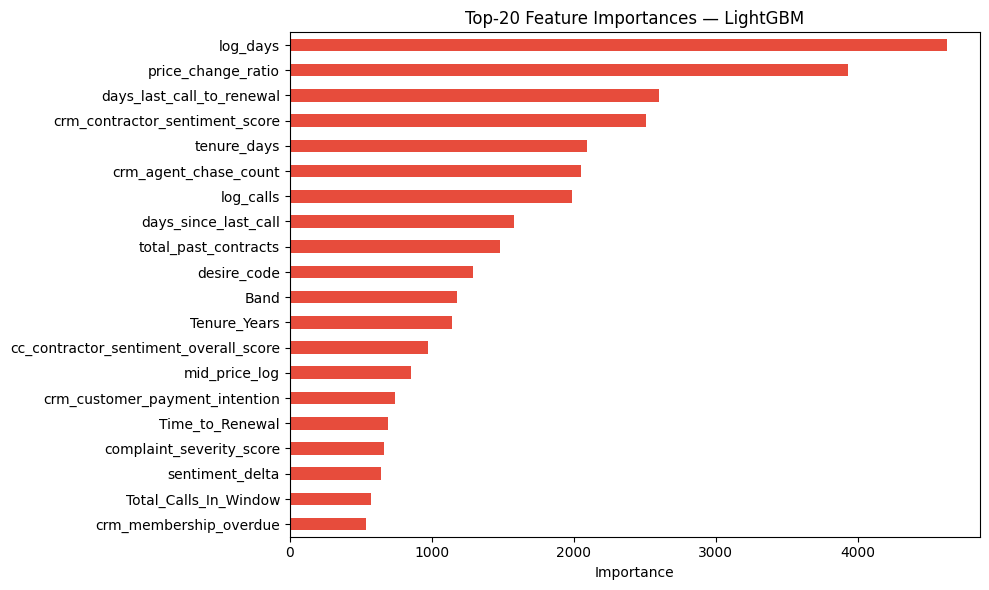

 Feature importance chart saved to feature_importance.png


In [27]:
# ── Feature importance (if available) ────────────────────────────────────────
estimator = final_pipeline.named_steps["model"]
if hasattr(estimator, "feature_importances_"):
    feat_imp = pd.Series(
        estimator.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(20)

    fig3, ax = plt.subplots(figsize=(10, 6))
    feat_imp.sort_values().plot(kind="barh", ax=ax, color="#e74c3c")
    ax.set_title(f"Top-20 Feature Importances — {final_best}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" Feature importance chart saved to feature_importance.png")


# Saving Model

In [38]:
joblib.dump(final_pipeline, model_file_path)

['/home/jackson-divakar/Documents/customer_renewal_analysis/models/01_churn_model_with_crm.pkl']